# Exemples d'articles par source

Ce notebook affiche **1 article représentatif** par source,  
avec le texte transformé et l'image associée.

| Source | Type | Images |
|--------|------|--------|
| fakeddit | Dataset Reddit | URL publique (imgur) |
| miragenews | Dataset HuggingFace | Fichier local |
| rss | Flux RSS live | URL publique |


In [10]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from pathlib import Path
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import textwrap

ROOT = Path('..').resolve()
PARQUET = ROOT / 'data' / 'processed' / 'transformed.parquet'
IMAGES_DIR = ROOT / 'data' / 'images'
RAW_DIR = ROOT / 'data' / 'raw'

df = pd.read_parquet(PARQUET)
print(f'Parquet chargé : {len(df):,} articles — {df.source.value_counts().to_dict()}')

Parquet chargé : 15,595 articles — {'mmfakebench': 10941, 'mediaeval': 2090, 'fakeddit': 1940, 'miragenews': 500, 'rss': 124}


In [11]:
import os
from functools import lru_cache
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

LABEL_COLORS = {"real": "#2ecc71", "fake": "#e74c3c", "unknown": "#95a5a6"}
CONF_SYMBOLS  = {"high": "●●●", "medium": "●●○", "low": "●○○"}


def load_image_from_url(url: str, timeout: int = 10) -> "Image.Image | None":
    try:
        r = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert("RGB")
    except Exception:
        return None


def load_image_from_path(path: str) -> "Image.Image | None":
    p = Path(path)
    if p.exists():
        return Image.open(p).convert("RGB")
    return None


@lru_cache(maxsize=1)
def _hf_mmfakebench_index() -> dict:
    """Charge MMFakeBench_val depuis HuggingFace et indexe par image_path.
    Mis en cache — chargé une seule fois par session kernel.
    """
    token = os.getenv("HF_TOKEN")
    if not token:
        print("⚠ HF_TOKEN manquant dans .env — images MMFakeBench non disponibles")
        return {}
    try:
        from datasets import load_dataset
        print("Chargement MMFakeBench depuis HuggingFace (première fois uniquement)…")
        ds = load_dataset(
            "liuxuannan/MMFakeBench", "MMFakeBench_val",
            token=token, trust_remote_code=False,
        )
        index = {}
        for split in ds.values():
            for row in split:
                key = str(row.get("image_path", ""))
                img = row.get("image")
                if key and img is not None:
                    index[key] = img.convert("RGB") if hasattr(img, "convert") else img
        print(f"Index MMFakeBench : {len(index)} images chargées ✓")
        return index
    except Exception as e:
        print(f"⚠ Impossible de charger MMFakeBench : {e}")
        return {}


def load_image_from_hf(image_path: str) -> "Image.Image | None":
    return _hf_mmfakebench_index().get(image_path)


def resolve_image(row: "pd.Series") -> "Image.Image | None":
    source = row["source"]
    if source in ("fakeddit", "rss") and row.get("image_url"):
        return load_image_from_url(row["image_url"])
    if source == "miragenews" and row.get("image_path"):
        local = row["image_path"].replace("/opt/airflow/", str(ROOT) + "/")
        return load_image_from_path(local)
    if source == "mmfakebench" and row.get("image_path"):
        return load_image_from_hf(row["image_path"])
    return None


def show_article(row: "pd.Series") -> None:
    img   = resolve_image(row)
    label = row.get("label", "unknown")
    conf  = row.get("label_confidence", "low")
    color = LABEL_COLORS.get(label, "#95a5a6")

    fig = plt.figure(figsize=(15, 6))
    fig.patch.set_facecolor("#f8f9fa")
    ax_text = fig.add_axes([0.02, 0.05, 0.56, 0.85])
    ax_img  = fig.add_axes([0.61, 0.05, 0.37, 0.85])

    ax_text.set_facecolor("white")
    ax_text.axis("off")

    title        = str(row.get("title", "—") or "—")
    text         = str(row.get("text",  "")  or "")
    text_preview = textwrap.fill(text[:700], width=72) + ("…" if len(text) > 700 else "")
    domain       = row.get("domain", "") or ""
    date         = str(row.get("date", "") or "")[:10]
    wc           = row.get("word_count", 0)

    ax_text.text(0.03, 0.97, f"[{label.upper()}]  {CONF_SYMBOLS.get(conf, '')}",
                 transform=ax_text.transAxes, fontsize=11, fontweight="bold",
                 color=color, va="top")
    ax_text.text(0.03, 0.89, textwrap.fill(title, 68),
                 transform=ax_text.transAxes, fontsize=10, fontweight="bold",
                 color="#2c3e50", va="top")
    ax_text.text(0.03, 0.78, f"{domain}  |  {date}  |  {wc} mots",
                 transform=ax_text.transAxes, fontsize=8, color="#7f8c8d", va="top")
    ax_text.text(0.03, 0.70, text_preview,
                 transform=ax_text.transAxes, fontsize=8.5, color="#34495e",
                 va="top", family="monospace")
    ax_text.axhline(y=0.84, xmin=0.02, xmax=0.98, color="#dfe6e9", linewidth=1)

    ax_img.set_facecolor("#ecf0f1")
    if img:
        ax_img.imshow(img, aspect="auto")
        ax_img.axis("off")
    else:
        ax_img.axis("off")
        ax_img.text(0.5, 0.55, "⚠", ha="center", va="center",
                    fontsize=28, color="#bdc3c7", transform=ax_img.transAxes)
        reason = {
            "mediaeval": "Images non distribuées\n(dataset académique)",
        }.get(row["source"], "Image non disponible")
        ax_img.text(0.5, 0.42, reason, ha="center", va="center",
                    fontsize=9, color="#95a5a6", transform=ax_img.transAxes)

    src_label = {
        "fakeddit":    "Fakeddit (Reddit)",
        "mmfakebench": "MMFakeBench (HuggingFace)",
        "miragenews":  "MirageNews (HuggingFace)",
        "mediaeval":   "MediaEval 2016",
        "rss":         "Flux RSS",
    }.get(row["source"], row["source"])
    fig.suptitle(f"Source : {src_label}", fontsize=13, fontweight="bold",
                 color="#2c3e50", y=0.98)
    plt.show()


print("Helpers chargés ✓")


Helpers chargés ✓


## 1. Fakeddit

Dataset Reddit multimodal. Labels : `real` / `fake` (2 et 6 classes). Images via URL Imgur/Reddit.

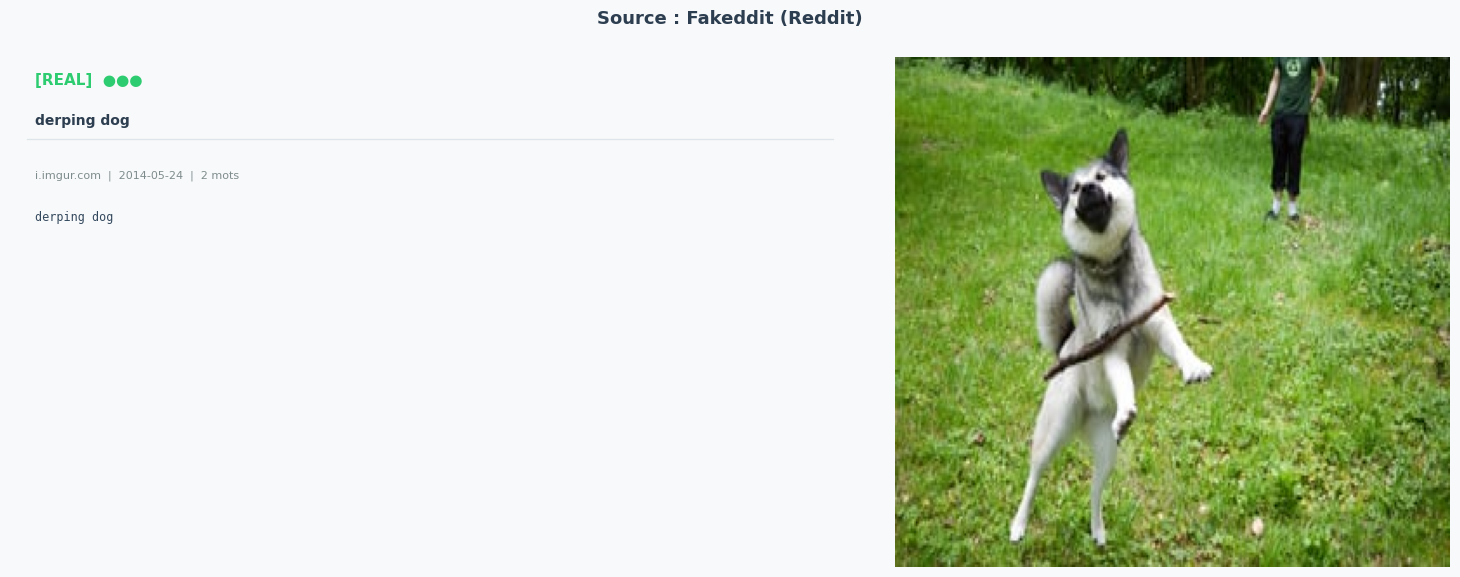

In [12]:
sample_fakeddit = (
    df[(df.source == 'fakeddit') & (df.text_image_ok == True)]
    .sample(1)
    .iloc[0]
)
show_article(sample_fakeddit)

## 2. MirageNews

Dataset HuggingFace d'articles de presse. Images téléchargées localement dans `data/images/miragenews/`.

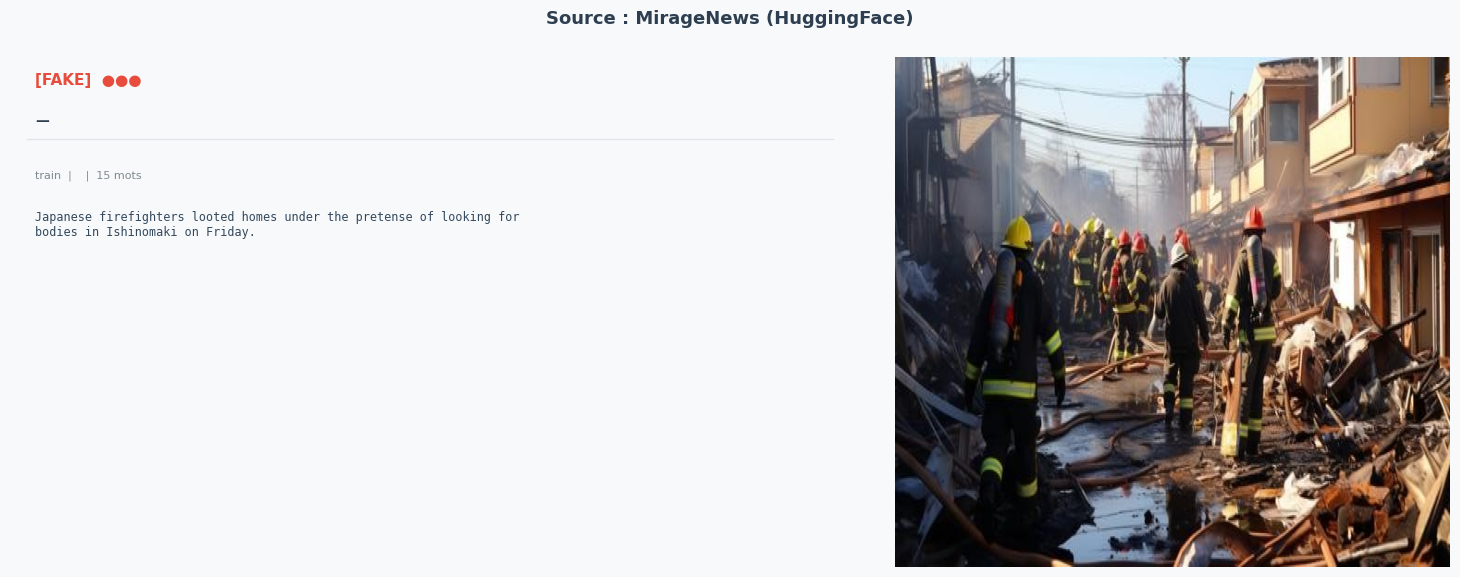

In [5]:
sample_mirage = (
    df[(df.source == 'miragenews') & (df.text_image_ok == True)]
    .sample(1)
    .iloc[0]
)
show_article(sample_mirage)

## 3. Flux RSS

Articles extraits en direct depuis des flux RSS (`Le Monde`, etc.). Images disponibles via URL publique.

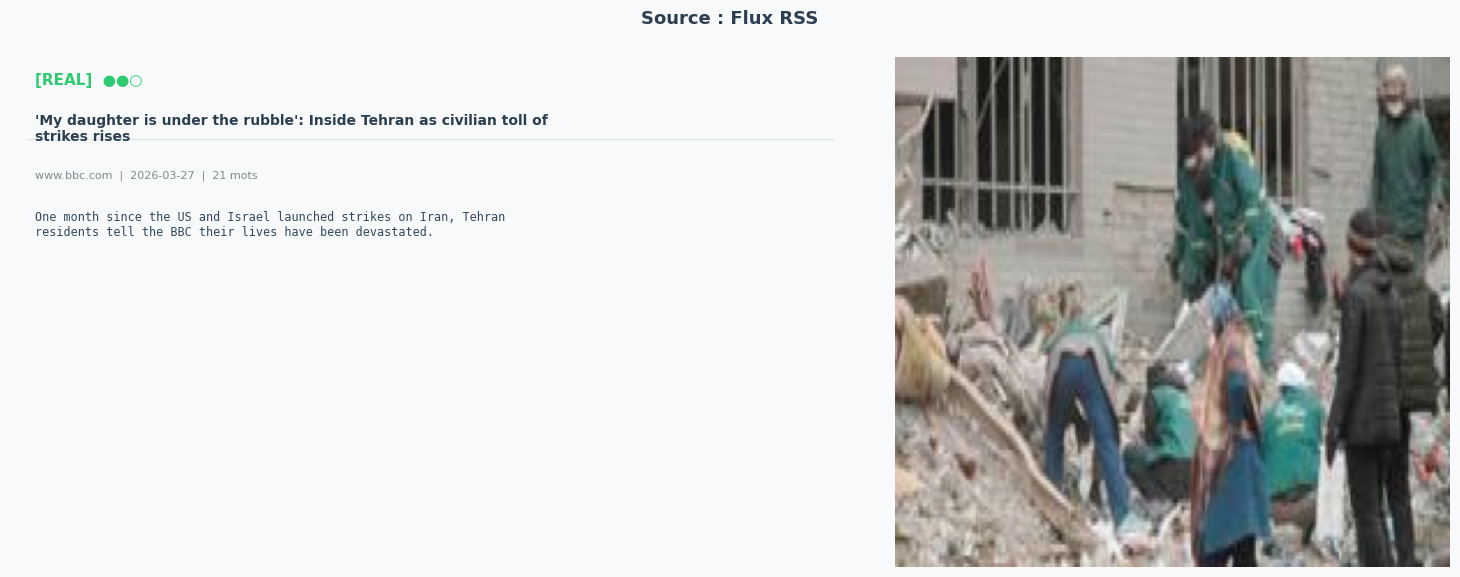

In [7]:
sample_rss = (
    df[(df.source == 'rss') & (df.text_image_ok == True)]
    .sample(1)
    .iloc[0]
)
show_article(sample_rss)

---
## Récapitulatif


In [8]:
summary = df.groupby('source').agg(
    total=('id', 'count'),
    avec_texte_et_image=('text_image_ok', 'sum'),
    pct_valide=('text_image_ok', lambda x: f"{x.mean()*100:.1f}%"),
    labels=('label', lambda x: x.value_counts().to_dict()),
).reset_index()
display(summary)

,source,total,avec_texte_et_image,pct_valide,labels
0,fakeddit,1940,1940,100.0%,"{'fake': 1126, 'real': 814}"
1,mediaeval,2090,2090,100.0%,"{'fake': 1141, 'real': 949}"
2,miragenews,500,500,100.0%,{'fake': 500}
3,mmfakebench,10941,10941,100.0%,"{'fake': 7641, 'real': 3300}"
4,rss,124,124,100.0%,"{'real': 104, 'unknown': 20}"
